# Handling Missing Values in Machine Learning 
# (Titanic Dataset)

Missing values are common in real-world datasets and must be handled properly before training machine learning models.

In this notebook, we explore different techniques to detect and handle missing values using the Titanic dataset.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Detect Missing Values

In [5]:
# Check missing values
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
# Count missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

## Visualizing Missing Values (Before Handling)

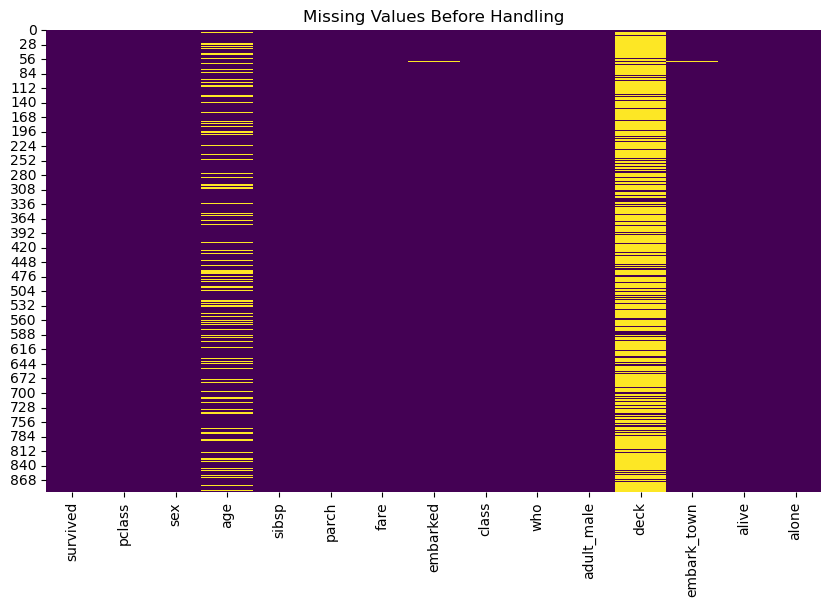

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Before Handling")

plt.show()

## Drop Columns with Too Many Missing Values

In [9]:
df.drop("deck", axis=1, inplace=True)

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

## Mean Imputation (Age Column)

In [12]:
df["age"] = df["age"].fillna(df["age"].mean())

In [13]:
df["age"].isnull().sum()

0

## Mode Imputation (Embarked Column)

In [15]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [16]:
df["embarked"].isnull().sum()

0

## Mode Imputation (Embark Town Column)

In [17]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

## Verify Remaining Missing Values

In [18]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Visualizing Missing Values (After Handling)

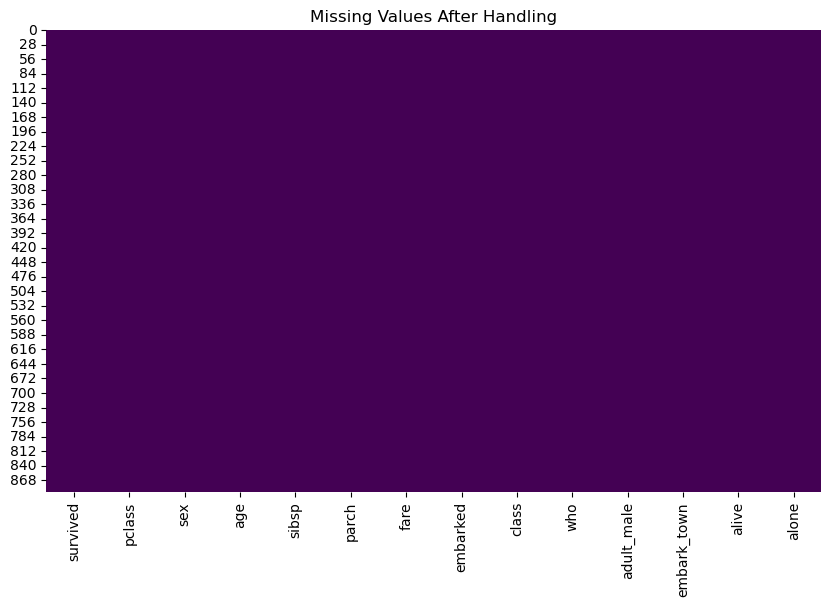

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values After Handling")

plt.show()

## KNN Imputation (Advanced Technique)

In [20]:
df_knn = sns.load_dataset("titanic")

In [21]:
numeric_df = df_knn.select_dtypes(include=np.number)

In [22]:
# Apply KNN imputer
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

numeric_imputed = imputer.fit_transform(numeric_df)

numeric_imputed = pd.DataFrame(
    numeric_imputed,
    columns=numeric_df.columns
)

numeric_imputed.head()

,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500


## Missing Values Comparison

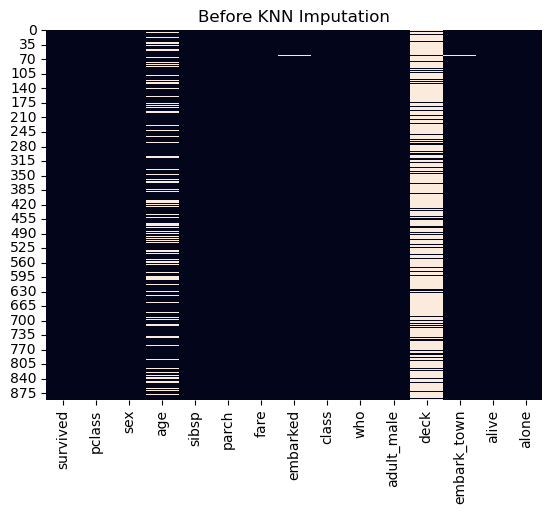

In [23]:
# Before cleaning
sns.heatmap(df_knn.isnull(), cbar=False)

plt.title("Before KNN Imputation")

plt.show()

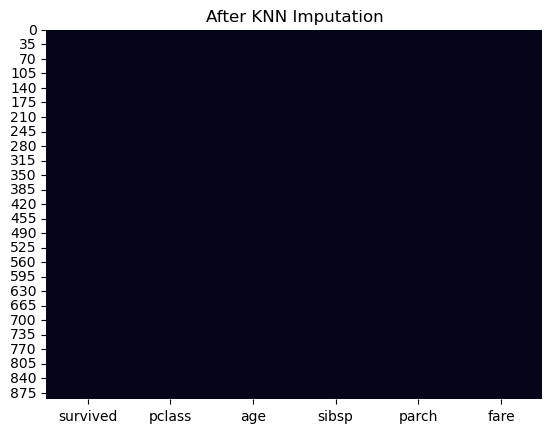

In [24]:
# After cleaning
sns.heatmap(numeric_imputed.isnull(), cbar=False)

plt.title("After KNN Imputation")

plt.show()

## Summary

In this notebook we learned:

- How to detect missing values
- How to measure missing-value percentage
- Dropping columns with excessive missing values
- Mean imputation for numerical features
- Mode imputation for categorical features
- Visualizing missing values using heatmaps
- Using KNN imputation as an advanced technique

Handling missing values properly improves dataset quality and leads to better machine learning model performance.